In [ ]:
from vdb.benchmark import (load_hdf5, brute_force_ground_truth, build_hnsw, sweep_hnsw, build_faiss_hnsw, sweep_faiss)

train, test, metric = load_hdf5("../fashion-mnist-784-euclidean.hdf5", n_train=20000, n_test=200)
gt = brute_force_ground_truth(train, test, k=10, metric=metric)

ef_values = [10, 25, 50, 100, 200]
mine, perm, t_build = build_hnsw(train, M=16, ef_construction=100, metric=metric)
faiss_idx, t_build_f = build_faiss_hnsw(train, M=16, ef_construction=100)

rows_mine = sweep_hnsw(mine, perm, test, gt, k=10, ef_values=ef_values)
rows_faiss = sweep_faiss(faiss_idx, test, gt, k=10, ef_values=ef_values)

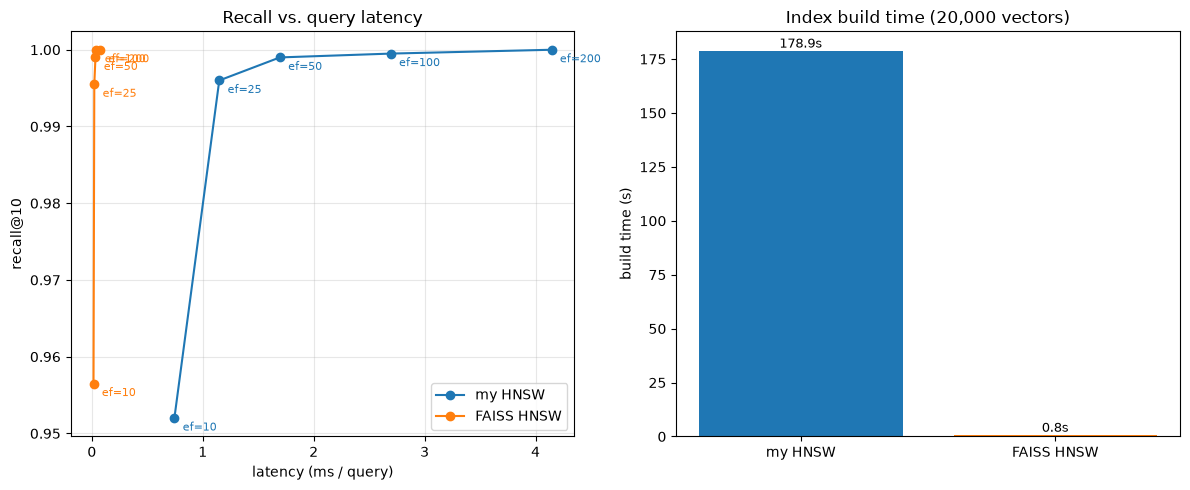

In [5]:
import matplotlib.pyplot as plt

fig, (ax_curve, ax_build) = plt.subplots(1, 2, figsize=(12, 5))

# --- recall vs. latency: better = up and to the LEFT (high recall, low latency) ---
for rows, label, color in [(rows_mine, "my HNSW", "C0"), (rows_faiss, "FAISS HNSW", "C1")]:
    xs = [r["ms_per_query"] for r in rows]
    ys = [r["recall"] for r in rows]
    ax_curve.plot(xs, ys, "-o", label=label, color=color)
    for r in rows:  # annotate each point with its ef_search
        ax_curve.annotate(f"ef={r['ef_search']}", (r["ms_per_query"], r["recall"]),
                          textcoords="offset points", xytext=(6, -9), fontsize=8, color=color)

ax_curve.set_xlabel("latency (ms / query)")
ax_curve.set_ylabel("recall@10")
ax_curve.set_title("Recall vs. query latency")
ax_curve.grid(True, alpha=0.3)
ax_curve.legend()

# --- build time: pure-Python insert vs. FAISS ---
labels = ["my HNSW", "FAISS HNSW"]
times = [t_build, t_build_f]
ax_build.bar(labels, times, color=["C0", "C1"])
ax_build.set_ylabel("build time (s)")
ax_build.set_title(f"Index build time ({len(train):,} vectors)")
for i, t in enumerate(times):
    ax_build.annotate(f"{t:.1f}s", (i, t), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()
